# Drum Track Separation Final Project 
### by: Rebecca Wroblewski

The goal of this project was to take a recording of a drum kit and separate the mix into audio segments for each type of drum being played.  The three types of drums that are assessed are the kick drum, snare drum, and the hi hat.

## Import Statements

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import librosa as lb
import matplotlib.pyplot as plt
import IPython.display as ipd
import scipy.io as sio
import scipy as sp
import glob
import csv 
import requests 
import xml.etree.ElementTree as ET

## Plot Functions

In [3]:
def plotLinearSpec(S, hop, sr):
    '''
    Plot of the input STFT as a linear spectogram 
    
    Arguments:
    S -- an input STFT matrix
    hop -- STFT analysis hop size in seconds 
    sr -- sampling rate
    
    Output:
    Plot of the input STFT as a linear spectogram
    '''
    
    maxY = S.shape[0]
    x = np.arange(S.shape[1])
    y = np.arange(0, maxY, step=(maxY//6)) 
    
    runTime = S.shape[1]
    tickLen = (sr//hop)//10
    numSecs = int((runTime*sr)//hop)
    maxF = S.shape[0]
    yHz = (y*sr)//1024
    
    x_label_list = (str(item) for item in range(numSecs))
    y_label_list = (str(item) for item in yHz) 

    plt.imshow(np.log2(abs(S)), origin='lower', aspect="auto", cmap = 'jet')
    
    plt.yticks(y, y_label_list)
    plt.xticks(x[::tickLen], x_label_list)
    plt.xlabel("Time (0.1 sec)")
    plt.ylabel("Freq (Hz)")

    plt.show()

In [4]:
def plotLinearH(S, hop, sr):
    '''
    Plot of the activations matrix 
    
    Arguments:
    S -- an input activations matrix
    hop -- STFT analysis hop size in seconds 
    sr -- sampling rate
    
    Output:
    Plot of the activations matrix
    '''
    
    maxY = S.shape[0]
    x = np.arange(S.shape[1])
    y = np.arange(0, maxY) 
    runTime = S.shape[1]
    tickLen = (sr//hop)//10
    numSecs = int((runTime*sr)//hop)
    
    x_label_list = (str(item) for item in range(numSecs))
    y_label_list = ["Kick", "Snare", "Hi Hat"]

    plt.imshow((S), origin='lower', aspect="auto", cmap = 'jet')
    
    plt.yticks(y, y_label_list)
    plt.xticks(x[::tickLen], x_label_list)
    plt.xlabel("Time (0.1 sec)")
    plt.ylabel("Drum")

    plt.show()

In [5]:
def plotLinearHon(S, hop, sr):
    '''
    Plot of the activations matrix with onsets
    
    Arguments:
    S -- an input activations matrix with onsets
    hop -- STFT analysis hop size in seconds 
    sr -- sampling rate
    
    Output:
    Plot of the activations matrix with onsets
    '''
    
    maxY = S.shape[0]
    x = np.arange(S.shape[1])
    y = np.arange(0, maxY) 
    runTime = S.shape[1]
    tickLen = (sr//hop)//10
    numSecs = int((runTime*sr)//hop)
    
    x_label_list = (str(item) for item in range(numSecs))
    y_label_list = ["Kick", "Kick Onset", "Snare", "Snare Onset", "Hi Hat", "Hi Hat Onset"]

    plt.imshow((S), origin='lower', aspect="auto", cmap = 'jet')
    
    plt.yticks(y, y_label_list)
    plt.xticks(x[::tickLen], x_label_list)
    plt.xlabel("Time (0.1 sec)")
    plt.ylabel("Drum")

    plt.show()

In [6]:
def plotLinearW(S, hop, sr):
    '''
    Plot of the templates matrix 
    
    Arguments:
    S -- an input templates matrix
    hop -- STFT analysis hop size in seconds 
    sr -- sampling rate
    
    Output:
    Plot of the templates matrix
    '''
    maxF = S.shape[1]
    x = np.arange(0, maxF, step=(maxF//6)) 
    xHz = (x*sr)//1024
    
    maxY = S.shape[0]
    x = np.arange(S.shape[1])
    y = np.arange(0, maxY) 
    runTime = S.shape[1]
    tickLen = (sr//hop)//10
    numSecs = int((runTime*sr)//hop)
    
    x_label_list = (str(item) for item in xHz)
    y_label_list = ["kick", "snare", "hi hat"]

    plt.imshow(np.log2(abs(S)), origin='lower', aspect="auto", cmap = 'jet')
    
    plt.yticks(y, y_label_list)
    plt.xticks(x, x_label_list)
    plt.xlabel("Frequency")
    plt.ylabel("Drum")

    plt.show()

## Template Functions

In [7]:
def avSmooth(signal, pointNum):
    '''
    An averaging filter
    
    Arguments:
    signal -- an input signal to be smoothed
    pointNum -- number of samples to average over
    
    Output:
    avSig -- the smoothed signal
    '''
    avSig = np.zeros(signal.shape)
    avSig[0] = signal[0]
    for x in range((len(signal)-1)):
        if(x>pointNum):
            temp = 0
            for y in range(pointNum):
                temp += (1/pointNum)*signal[x-y]
            avSig[x] = temp
        elif(x > 0):
            temp = 0
            for y in range(x):
                temp += (1/x)*signal[x-y]
            avSig[x] = temp
    return avSig

In [8]:
def createTemplate(indir, res):
    '''
    Creates an average spectrum of all the elements in an input directory
    
    Arguments:
    indir -- the specified directory
    res -- fft size
    
    Output:
    temp/count -- average spectrum
    '''
    
    string = (""+indir+"/*.wav")
    count = 0
    temp = np.zeros((res))
    for x in glob.glob(string):
        file, sr = lb.core.load(x)
        stftTemp = lb.core.stft(file, n_fft = 2048, hop_length = 128)
        temp = np.mean(abs(stftTemp), axis=1)
        count += 1
    return temp/count

In [9]:
def createTemplateSmooth(indir, res, num):
    '''
    Creates an average spectrum of all the elements in an input directory
    Templates are smoothed using an averaging filter
    
    Arguments:
    indir -- the specified directory
    res -- fft size
    num -- number of samples to average over
    
    Output:
    template -- average spectrum
    '''
    
    string = (""+indir+"/*.wav")
    count = 0
    temp = np.zeros((res))
    for x in glob.glob(string):
        file, sr = lb.core.load(x)
        stftTemp = lb.core.stft(file, n_fft = 2048, hop_length = 128)
        temp = np.mean(abs(stftTemp), axis=1)
        count += 1
    template = temp/count
    template = avSmooth(template, num)
    return template

In [10]:
def createTemplateSmoothThresh(indir, res, numF, T):
    '''
    Creates an average spectrum of all the elements in an input directory
    Templates are smoothed using an averaging filter
    Template elements under a certain threshold are set to zero
    
    Arguments:
    indir -- the specified directory
    res -- fft size
    num -- number of samples to average over
    T -- factor below max template value to threshold over
    
    Output:
    template -- average spectrum
    '''
    
    string = (""+indir+"/*.wav")
    count = 0
    temp = np.zeros((res))
    for x in glob.glob(string):
        file, sr = lb.core.load(x)
        stftTemp = lb.core.stft(file, n_fft = 2048, hop_length = 128)
        temp = np.mean(abs(stftTemp), axis=1)
        count += 1
    template = temp/count
    template = avSmooth(template, numF)
    thresh = np.max(template)/T
    for i in range(len(template)):
        if (template[i]<thresh):
            template[i] = 0
    return template

## Template Initialization

### Kick Drum

Below is the audio for, and a visualization of the spectrum for a single kick drum hit.

In [11]:
file, sr = lb.core.load("kicks\kick_feltbeater_medium2.wav")
ipd.Audio(file[0:22050], rate=sr)

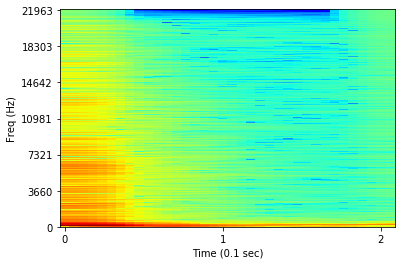

(1025, 36)

In [12]:
stftKick = lb.core.stft(file, n_fft = 2048, hop_length = 128)
plotLinearSpec(stftKick, 128, sr)
stftKick.shape

Below the templates are initialized.  Both those with and without thresholding.

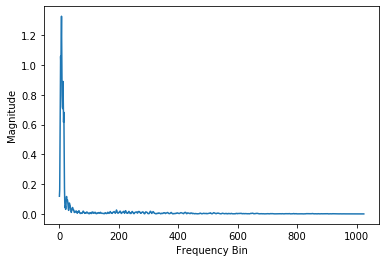

In [13]:
kickTemplateNC = createTemplate("kicks", 1025)
plt.plot(kickTemplateNC)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

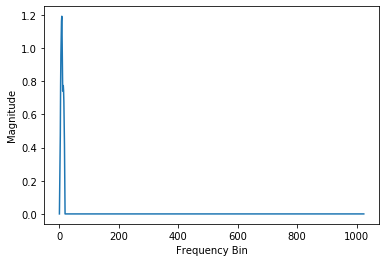

In [14]:
kickTemplate = createTemplateSmoothThresh('kicks', 1025, 3, 10)
plt.plot(kickTemplate)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

### Snare Drum

Below is the audio for, and a visualization of the spectrum for a single snare drum hit.

In [15]:
file, sr = lb.core.load("snares\snare-2.wav")
ipd.Audio(file[0:22050], rate=sr)

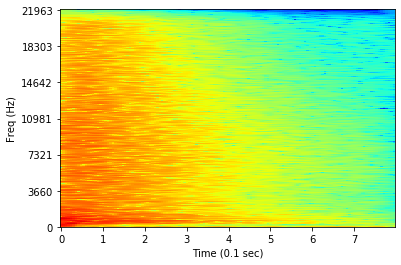

In [16]:
stftSnare = lb.core.stft(file, n_fft = 2048, hop_length = 128)
plotLinearSpec(stftSnare, 128, sr)

Below the templates are initialized.  Both those with and without thresholding.

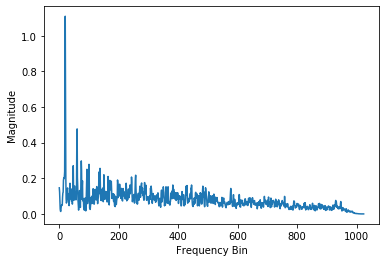

In [17]:
snareTemplateNC = createTemplate("snares", 1025)
plt.plot(snareTemplateNC)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

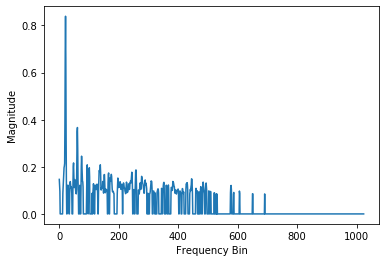

In [18]:
snareTemplate = createTemplateSmoothThresh("snares", 1025, 3, 10)
plt.plot(snareTemplate)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

### Hi Hat

Below is the audio for, and a visualization of the spectrum for a single hi hat hit.

In [19]:
file, sr = lb.core.load("hihats\CYCdh_Sab_ClHat-03.wav")
ipd.Audio(file[0:22050], rate=sr)

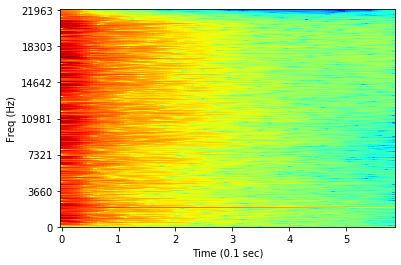

In [20]:
stftHH = lb.core.stft(file, n_fft = 2048, hop_length = 128)
plotLinearSpec(stftHH, 128, sr)

Below the templates are initialized. Both those with and without thresholding.  For the hi hat template, the lowest 20 frequency bins.  These low frequency components are not a large component of the hi hat spectrum and reduce the overlap of the hi hat spectrum with the kick drum spectrum, which improves the template updating performance.

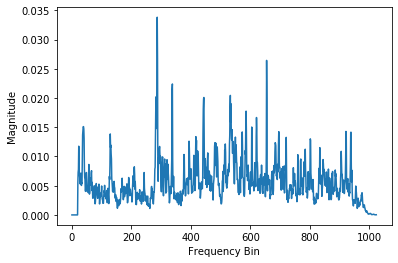

In [21]:
hhTemplateNC = createTemplate("hihats", 1025)
hhTemplateNC[0:20] = 0
plt.plot(hhTemplateNC)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

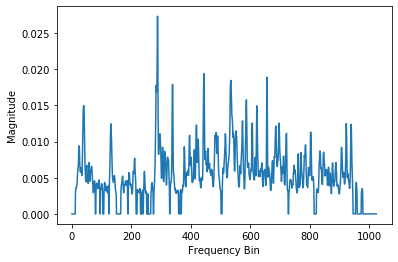

In [22]:
hhTemplate = createTemplateSmoothThresh("hihats", 1025, 3, 10)
plt.plot(hhTemplate)
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()

## NMF Functions

In [23]:
def runNMF(V, W_0, H_0, convDiff):
    '''
    Runs NMF, finding decomposed matrices W and H where the product of W and H is approximately input matrix V
    
    Arguments:
    V -- an input matrix
    W_0 -- the first approximation of matrix W
    H_0 -- the first approximation of matrix H
    convDiff -- the difference between H elements required to continue iteration
    
    Output:
    H -- the approximated output H matrix
    W -- the approximated output W matrix
    count -- the number of iterations performed
    '''
    H = H_0
    W = W_0
    Hold = H_0+1
    count = 0
    
    while(np.any(abs(Hold-H)>=convDiff)):
        Hold = H
        H = np.divide((np.multiply(H, np.matmul(np.transpose(W),V))), np.matmul(np.matmul(np.transpose(W),W),H)+1e-9)
        W = np.divide((np.multiply(W, np.matmul(V,np.transpose(H)))), np.matmul(np.matmul(W,H),np.transpose(H))+1e-9)
        count+=1
        
    return H, W, count

In [24]:
def runNMF_H(V, W_0, H_0, convDiff):
    '''
    Runs NMF, finding decomposed matrices W and H where the product of W and H is approximately input matrix V
    In this iteration, W is kept constant and only H is updated
    
    Arguments:
    V -- an input matrix
    W_0 -- the first approximation of matrix W
    H_0 -- the first approximation of matrix H
    convDiff -- the difference between H elements required to continue iteration
    
    Output:
    H -- the approximated output H matrix
    W -- the approximated output W matrix
    count -- the number of iterations performed
    '''
    H = H_0
    W = W_0
    Hold = H_0+1
    count = 0
    
    while(np.any(abs(Hold-H)>=convDiff)):
        Hold = H
        H = np.divide((np.multiply(H, np.matmul(np.transpose(W),V))), np.matmul(np.matmul(np.transpose(W),W),H)+1e-9)
        count+=1
        
    return H, W, count

In [25]:
def runNMF_W(V, W_0, H_0, convDiff):
    '''
    Runs NMF, finding decomposed matrices W and H where the product of W and H is approximately input matrix V
    In this iteration, H is kept constant and only W is updated
    
    Arguments:
    V -- an input matrix
    W_0 -- the first approximation of matrix W
    H_0 -- the first approximation of matrix H
    convDiff -- the difference between H elements required to continue iteration
    
    Output:
    H -- the approximated output H matrix
    W -- the approximated output W matrix
    count -- the number of iterations performed
    '''
    H = H_0
    W = W_0
    Wold = W_0+1
    count = 0
    
    while(np.any(abs(Wold-W)>=convDiff)):
        Wold = W
        W = np.divide((np.multiply(W, np.matmul(V,np.transpose(H)))), np.matmul(np.matmul(W,H),np.transpose(H))+1e-9)
        count+=1
        
    return H, W, count

## Drum Track Separation Specific Functions

In [26]:
def createAllTemplates(kickDir, snareDir, HHDir):
    '''
    Creates a matrix of templates from the input directories specified
    Creates matrices for both thresholded and non-thresholded templates
    
    Arguments:
    kickDir -- directory of kick drum hits
    snareDir -- directory of snare drum hits
    HHDir -- directory of hi hat hits
    
    Output:
    templates -- a matrix of thresholded templates
    templatesNC -- a matrix of non-thresholded templates
    '''
    templates = np.zeros((3, 1025))
    templatesNC = np.zeros((3, 1025))
    templatesNC[0] = createTemplate(kickDir, 1025)
    templates[0] = createTemplateSmoothThresh(kickDir, 1025, 3, 10)
    templatesNC[1] = createTemplate(snareDir, 1025)
    templates[1] = createTemplateSmoothThresh(snareDir, 1025, 3, 10)
    templateTemp = createTemplate(HHDir, 1025)
    templateTemp[0:20] = 0
    templatesNC[2] = templateTemp
    templates[2] = createTemplateSmoothThresh(HHDir, 1025, 3, 10)
    return templates, templatesNC

In [27]:
def createCutTemplates(kickDir, snareDir, HHDir):
    '''
    Creates a matrix of templates from the input directories specified
    Only creates matrices for thresholded templates
    
    Arguments:
    kickDir -- directory of kick drum hits
    snareDir -- directory of snare drum hits
    HHDir -- directory of hi hat hits
    
    Output:
    templates -- a matrix of thresholded templates
    '''
    templates = np.zeros((3, 1025))
    templates[0] = createTemplateSmoothThresh(kickDir, 1025, 3, 10)
    templates[1] = createTemplateSmoothThresh(snareDir, 1025, 3, 10)
    templates[2] = createTemplateSmoothThresh(HHDir, 1025, 3, 10)
    return templates

In [28]:
def runNMF_1(absStft, templates):
    '''
    Runs the first round of NMF, only updating the activations matrix
    
    Arguments:
    absStft -- the absolute value of each element of the stft matrix
    templates -- matrix of thresholded templates
    
    Output:
    H -- output activations matrix
    '''
    row, col = absStft.shape
    maxVal = np.max(absStft)
    H0 = np.random.rand(3, col)*maxVal
    W0 = np.zeros((row, 3))
    W0[:, 0] = templates[0]
    W0[:, 1] = templates[1]
    W0[:, 2] = templates[2]
    H, W, count = runNMF_H(absStft, W0, H0, 0.0005)
    return H

In [29]:
def runNMF_1_file(file, templates):
    '''
    Runs the first round of NMF, only updating the activations matrix
    
    Arguments:
    file -- input audio file
    templates -- matrix of thresholded templates
    
    Output:
    H -- output activations matrix
    '''
    
    file, sr = lb.core.load(file)
    stft = lb.core.stft(file, n_fft = 2048, hop_length = 128)
    absStft = abs(stft)
    row, col = absStft.shape
    maxVal = np.max(absStft)
    H0 = np.random.rand(3, col)*maxVal
    W0 = np.zeros((row, 3))
    W0[:, 0] = templates[0]
    W0[:, 1] = templates[1]
    W0[:, 2] = templates[2]
    H = runNMF_1(absStft, templates)
    return H

In [30]:
def splitMat(H):
    '''
    Splits the H matrix, adding drum onsets
    
    Arguments:
    H -- activations matrix
    
    Output:
    H02 -- output activations matrix with onsets
    '''
    
    cols = H.shape[1]
    H02 = np.zeros((6, cols))
    for x in range(3):
        colNum = 0
        while (colNum < cols):
            if (H[x, colNum] < 7):
                colNum += 1
            else:
                if(colNum > 0 and colNum+5<cols):
                    if(np.all(H[x, colNum:colNum+5] >= 7) and H[x, colNum-1] < 7):
                        H02[((2*x)+1), colNum:colNum+5] = H[x,colNum:colNum+5]
                        colNum += 5
                    else:
                        H02[x*2, colNum] = H[x,colNum]
                        colNum += 1
                else:
                    H02[x*2, colNum] = H[x,colNum]
                    colNum += 1
    return H02

In [31]:
def separateEstSpect(W, H):
    '''
    Separates the output NMF H matrix by drum
    Multiplies each separated drum H matrix by the output NMF W matrix
    
    Arguments:
    W -- NMF output W matrix (3 templates)
    H -- NMF output H matrix
    
    Output:
    WHkick -- product of W and the kick template
    WHsnare -- product of W and the snare template
    WHhh -- product of W and the hi hat template
    '''
    
    Hkick = np.zeros(H.shape)
    Hsnare = np.zeros(H.shape)
    Hhh = np.zeros(H.shape)
    
    Hkick[0, :] = H[0, :]
    Hsnare[1, :] = H[1, :]
    Hhh[2, :] = H[2, :]
    
    WHkick = np.matmul(W, Hkick)
    WHsnare = np.matmul(W, Hsnare)
    WHhh = np.matmul(W, Hhh)
    
    return WHkick, WHsnare, WHhh

In [32]:
def separateEstSpect2(W, H):
    '''
    Separates the output NMF H matrix by drum (accounts for onset templates)
    Multiplies each separated drum H matrix by the output NMF W matrix
    
    Arguments:
    W -- NMF output W matrix (6 templates)
    H -- NMF output H matrix
    
    Output:
    WHkick -- product of W and the kick template
    WHsnare -- product of W and the snare template
    WHhh -- product of W and the hi hat template
    '''
    
    Hkick = np.zeros(H.shape)
    Hsnare = np.zeros(H.shape)
    Hhh = np.zeros(H.shape)
    
    Hkick[0:2, :] = H[0:2, :]
    Hsnare[2:4, :] = H[2:4, :]
    Hhh[4:6, :] = H[4:6, :]

    
    WHkick = np.matmul(W, Hkick)
    WHsnare = np.matmul(W, Hsnare)
    WHhh = np.matmul(W, Hhh)
    
    
    return WHkick, WHsnare, WHhh

In [33]:
def softMasks(W, H, stft, param):
    '''
    Applys the soft masks reconstruction method
    
    Arguments:
    W -- NMF output W matrix
    H -- NMF output H matrix
    stft -- original stft matrix
    param -- 1 if onsets are not used, 2 if onsets are used
    
    Output:
    leftTrack -- left hand audio file
    rightTrack -- right hand audio file
    '''
    
    if (param == 1):
        WHkick, WHsnare, WHhh = separateEstSpect(W, H)
    else:
        WHkick, WHsnare, WHhh = separateEstSpect2(W, H)
    WHe = np.matmul(W, H) + 1e-9
    
    Mkick = np.divide(WHkick, WHe)
    Msnare = np.divide(WHsnare, WHe)
    Mhh = np.divide(WHhh, WHe)
    
    stftKick = np.multiply(Mkick, stft)
    stftSnare = np.multiply(Msnare, stft)
    stftHH = np.multiply(Mhh, stft)
    
    kickTrack = lb.core.istft(stftKick, hop_length=128)
    snareTrack = lb.core.istft(stftSnare, hop_length=128)
    HiHatTrack = lb.core.istft(stftHH, hop_length=128)
    
    return kickTrack, snareTrack, HiHatTrack

In [34]:
def runNMF_2_reconstruct(H02, H, stft, templatesNC, files):
    '''
    Runs the second round of NMF, only updating the templates matrix
    Reconstructs blocks of audio and assembles them together
    Outputs isolates tracks
    
    Arguments:
    H -- NMF activations matrix
    H02 -- NMF activations matrix with onsets
    stft -- original stft matrix
    templatesNC -- non-thresholded templates
    files -- input audio files for each output track
    
    Output:
    files -- matrix of output files, one for each drum: kick, snare, and hi hat
    '''
    row, cols = stft.shape
    W02 = np.zeros((row, 6))
    W02[:, 0] = templatesNC[0]
    W02[:, 1] = templatesNC[0]
    W02[:, 2] = templatesNC[1]
    W02[:, 3] = templatesNC[1]
    W02[:, 4] = templatesNC[2]
    W02[:, 5] = templatesNC[2]
    absStft = abs(stft)
    for i in range(cols-1):
        if(i==0):
            startInd = 0
        elif(np.any(H[:, i]>7) and np.all(H[:, i+1]<=7)):
            endInd = i+1
            Htemp, Wtemp, countTemp = runNMF_W(absStft[:, startInd:endInd], W02, H02[:, startInd:endInd], 0.0005)
            kickTrackTemp, snareTrackTemp, HHTrackTemp = softMasks(Wtemp, H02[:, startInd:endInd], stft[:, startInd:endInd], 2)
            
            files[0][startInd*128:((endInd-1)*128)] = kickTrackTemp
            files[1][startInd*128:((endInd-1)*128)] = snareTrackTemp
            files[2][startInd*128:((endInd-1)*128)] = HHTrackTemp
            startInd = i+1
        elif(i == cols-2):
            endInd = cols-2
            
            Htemp, Wtemp, countTemp = runNMF_W(absStft[:, startInd:endInd], W02, H02[:, startInd:endInd], 0.0005)
            kickTrackTemp, snareTrackTemp, HHTrackTemp = softMasks(Wtemp, H02[:, startInd:endInd], stft[:, startInd:endInd], 1)
            
            files[0][startInd*128:((endInd-1)*128)] = kickTrackTemp
            files[1][startInd*128:((endInd-1)*128)] = snareTrackTemp
            files[2][startInd*128:((endInd-1)*128)] = HHTrackTemp
            
    return files

In [35]:
def runDTS(file):
    '''
    Runs the entire Drum Track Separation flow
    
    Arguments:
    file -- input drum kit mix file
    
    Output:
    files -- matrix of output files, one for each drum: kick, snare, and hi hat
    '''
    
    templates, templatesNC = createAllTemplates('kicks', 'snares', 'hihats')
    file, sr = lb.core.load(file)
    files = np.zeros((3, file.shape[0]))
    stft = lb.core.stft(file, n_fft = 2048, hop_length = 128)
    absStft = abs(stft)
    H = runNMF_1(absStft, templates)
    H02 = splitMat(H)
    files= runNMF_2_reconstruct(H02, H, stft, templatesNC, files)
    
    return files

## Example DTS Run
Separated run of Drum Track Separation on the first 2 seconds of the following audio drum kit mix.

In [36]:
file, sr = lb.core.load("mixes/real/RealDrum01_03#MIX.wav")
ipd.Audio(file[0:48000], rate=sr)

First, the STFT is taken of the audio.

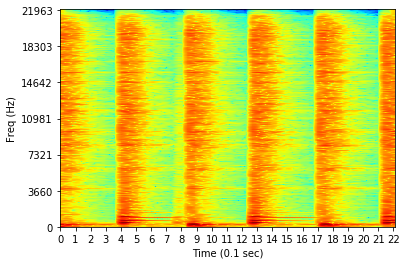

In [37]:
files = np.zeros((3, 48000))
stft = lb.core.stft(file[0:48000], n_fft = 2048, hop_length = 128)
absStft = abs(stft)
plotLinearSpec(absStft, 128, 22050)

The templates are then initialized from the files in three directories.

C:\Users\rebec\Anaconda3\envs\e207\lib\site-packages\ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in log2


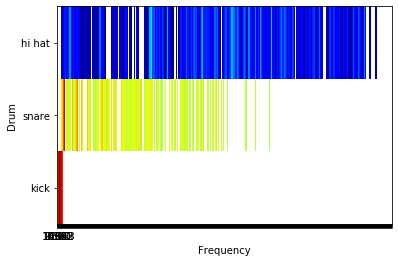

In [38]:
templates, templatesNC = createAllTemplates('kicks', 'snares', 'hihats')
plotLinearW(templates, 128, 22050)

C:\Users\rebec\Anaconda3\envs\e207\lib\site-packages\ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in log2


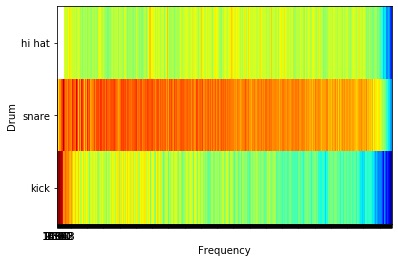

In [39]:
plotLinearW(templatesNC, 128, 22050)

NMF is run, only updating the activations matrix.

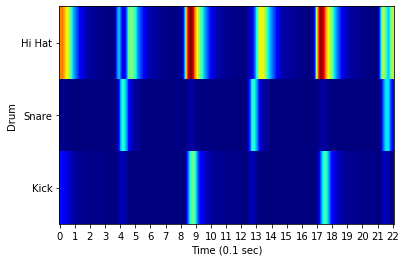

In [40]:
H = runNMF_1(absStft, templates)
plotLinearH(H, 128, 22050)

This activations matrix is split to add in drum onsets.

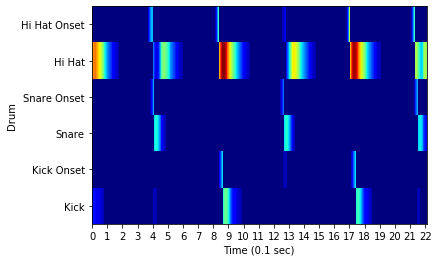

In [41]:
H02 = splitMat(H)
plotLinearHon(H02, 128, 22050)

NMF is then run again, in blocks, to update the templates matrix.  The audio is then reconstructed in these separated blocks and reassembled into the tracks for each drum type.  The soft masking approach is used for reconstruction.

In [42]:
files = runNMF_2_reconstruct(H02, H, stft, templatesNC, files)
ipd.Audio(files[0], rate=sr)

In [43]:
ipd.Audio(files[1], rate=sr)

In [44]:
ipd.Audio(files[2], rate=sr)

## Full DTS Run
The process explained above is all condensed into the runDTS function.  The following shows an example of the whole process run again using the full clip.  This process might take a while.

In [45]:
file, sr = lb.core.load("mixes/real/RealDrum01_03#MIX.wav")
ipd.Audio(file, rate=sr)

In [46]:
files= runDTS("mixes/real/RealDrum01_03#MIX.wav")
ipd.Audio(files[0], rate=sr)

In [47]:
ipd.Audio(files[1], rate=sr)

In [48]:
ipd.Audio(files[2], rate=sr)

## Performance Statistic
The following functions are used to calculate the performance statistics.

In [49]:
def parseXML(xmlfile): 
    '''
    parses through the IDMT-SMT Drums annotations
    creates an array of tuples with onset times and the corresponding drum that is played
    
    Arguments:
    xmlfile -- input annotation file
    
    Output:
    annotations -- array of tuples with onset times and a number for the drum played
    '''
    
    tree = ET.parse(xmlfile) 
  
    # get root element 
    root = tree.getroot() 
  
    # create empty list for annotations 
    annotations = [] 
  
    # iterate through annotations
    for event in root.iter('event'):
        
        time = float(event.find('onsetSec').text)
        instr = event.find('instrument').text
        
        #store onset time and instrument type played
        temp = (time, instr)

        # append to annotations list 
        annotations.append(temp) 
      
    # return annotations list 
    return annotations

In [50]:
def changeAnnot(annotations, fs, hop):
    '''
    separates the array of tuples with onset times and drum number into two arrays
    the index of the array corresponds to a particular drum event
    
    Arguments:
    annotations -- array of tuples with onset times and a number for the drum played
    fs -- sampling rate
    hop -- hop size of fft
    
    Output:
    annotDrum -- array with the drum number for an event
    annotTime -- array with the onset time for an event
    '''
    
    length = len(annotations)
    annotDrum = np.zeros((1,length))
    annotTime = np.zeros((1,length))
    for ind in range(length):
        annot = annotations[ind]
        time = annot[0]
        instr = annot[1]
        binNum = int(time*fs//hop)
        annotTime[0, ind] = binNum
        if instr == 'HH':
            inNum = 2
        if instr == 'SD':
            inNum = 1
        if instr == 'KD':
            inNum = 0
        annotDrum[0, ind] = inNum
    return annotDrum, annotTime

In [51]:
def checkH(annotations, H, fs, hop):
    '''
    Goes through the annotations and compares to the activations matrix
    Gives the amount of annotations correctly identified at the right time
    
    Arguments:
    annotations -- array of tuples with onset times and a number for the drum played
    H -- activations matrix
    fs -- sampling rate
    hop -- hop size of fft
    
    Output:
    rightCount -- number of annotations correctly identified
    totalCount -- number of annotations
    '''
    
    rightCount = 0
    totalCount = 0
    for annot in annotations:
        time = annot[0]
        instr = annot[1]
        binNum = int(time*fs//hop)
        totalCount += 1
        if instr == 'HH':
            inNum = 2
        if instr == 'SD':
            inNum = 1
        if instr == 'KD':
            inNum = 0
        if(H[inNum,binNum]>7):
            rightCount += 1
    return rightCount, totalCount

In [52]:
def checkHneg(annotDrum, annotTime, H, fs, hop):
    '''
    Goes through the activations matrix and compares to the annotations
    Gives the number of drum hits identified by the activations matrix that correspond to an annotation
    
    Arguments:
    annotDrum -- array with the drum number for an event
    annotTime -- array with the onset time for an event
    H -- activations matrix
    fs -- sampling rate
    hop -- hop size of fft
    
    Output:
    right -- number of identified hits corresponding to annotations
    total -- number of total identified hits
    '''
    
    right = 0
    total = 0
    check = 0
    temp = np.where(H>7, H, H*0)
    arr = np.nonzero(temp)
    for ind in range(len(arr[0])):
        if(ind>0):
            if(arr[1][ind] != (arr[1][ind-1]+1)):
                total += 1
                rightTemp = 0
                argind = np.argwhere((annotTime[0] < arr[1][ind]+10) & (annotTime[0] > arr[1][ind]-10))
                for arg in argind:
                    if(annotDrum[0][arg[0]] == arr[0][ind]):
                        rightTemp = 1
                right += rightTemp
            elif(arr[0][ind] != arr[0][ind-1]):
                total += 1
                rightTemp = 0
                argind = np.argwhere((annotTime[0] < arr[1][ind]+10) & (annotTime[0] > arr[1][ind]-10))
                for arg in argind:
                    if(annotDrum[0][arg[0]] == arr[0][ind]):
                        rightTemp = 1
                right += rightTemp
        else:
            total += 1
            rightTemp = 0
            argind = np.argwhere((annotTime[0] < arr[1][ind]+10) & (annotTime[0] > arr[1][ind]-10))
            if(len(argind>0)):
                for arg in argind:
                    if(annotDrum[0][arg[0]] == arr[0][ind]):
                        rightTemp = 1
            right += rightTemp
        
    return right, total

In [53]:
def runBenchmarkPos(indir):
    '''
    Runs through all the audio clips in the IDMT-SMT dataset
    generates true positive score for algorithm
    
    Arguments:
    indir -- IDMT-SMT Drums directory
    
    Output:
    numRight/total -- true positive score
    '''
    
    string = (""+indir+"/*.wav")
    numRight = 0
    total = 0
    templates = createCutTemplates("kicks", "snares", "hihats")
    for x in glob.glob(string):
        H = runNMF_1_file(x, templates)
        numCut = len(indir)
        cutF = x[numCut+1::]
        cutB = cutF[:(len(cutF)-4)]
        filepath = "drumDatabase/annotation_xml/" + cutB + ".xml"
        annotate = parseXML(filepath)
        right, count = checkH(annotate, H, 22050, 128)
        total += count
        numRight += right
        print(cutB)
    return numRight/total

In [54]:
def runBenchmarkNeg(indir):
    '''
    Runs through all the audio clips in the IDMT-SMT dataset
    generates false positive score for algorithm
    
    Arguments:
    indir -- IDMT-SMT Drums directory
    
    Output:
    (1- (numRight/total)) -- false positive score 
    '''
    
    string = (""+indir+"/*.wav")
    numRight = 0
    total = 0
    templates = createCutTemplates("kicks", "snares", "hihats")
    for x in glob.glob(string):
        H = runNMF_1_file(x, templates)
        numCut = len(indir)
        cutF = x[numCut+1::]
        cutB = cutF[:(len(cutF)-4)]
        filepath = "drumDatabase/annotation_xml/" + cutB + ".xml"
        annotate = parseXML(filepath)
        annotDrum, annotTime = changeAnnot(annotate, 22050, 128)
        right, count = checkHneg(annotDrum, annotTime, H, 22050, 128)
        total += count
        numRight += right
        print(cutB)
    return (1 - (numRight/total))

### Running Benchmarks For True Positive and False Positive Scores
#### Disclaimer: This takes a very, very long time to run
To run a smaller sub-section of the benchmark tests you can run the commented out tests at the bottom that run on a smaller subset of the database.

In [55]:
runBenchmarkPos("mixes/all")

RealDrum01_01#MIX
RealDrum01_02#MIX
RealDrum01_03#MIX
RealDrum01_04#MIX
RealDrum01_05#MIX
RealDrum01_06#MIX
RealDrum01_07#MIX
RealDrum01_08#MIX
RealDrum01_09#MIX
RealDrum01_10#MIX
RealDrum01_11#MIX
RealDrum01_12#MIX
RealDrum01_13#MIX
TechnoDrum01_00#MIX
TechnoDrum01_01#MIX
TechnoDrum01_02#MIX
TechnoDrum01_03#MIX
TechnoDrum01_04#MIX
TechnoDrum01_05#MIX
TechnoDrum01_06#MIX
TechnoDrum01_07#MIX
TechnoDrum01_08#MIX
TechnoDrum01_09#MIX
TechnoDrum02_00#MIX
WaveDrum01_00#MIX
WaveDrum01_01#MIX
WaveDrum01_02#MIX
WaveDrum01_03#MIX
WaveDrum01_04#MIX
WaveDrum01_05#MIX
WaveDrum01_06#MIX
WaveDrum01_07#MIX
WaveDrum01_08#MIX
WaveDrum01_09#MIX
WaveDrum02_01#MIX
WaveDrum02_02#MIX
WaveDrum02_03#MIX
WaveDrum02_04#MIX
WaveDrum02_05#MIX
WaveDrum02_06#MIX
WaveDrum02_07#MIX
WaveDrum02_08#MIX
WaveDrum02_09#MIX
WaveDrum02_10#MIX
WaveDrum02_11#MIX
WaveDrum02_12#MIX
WaveDrum02_13#MIX
WaveDrum02_14#MIX
WaveDrum02_15#MIX
WaveDrum02_16#MIX
WaveDrum02_17#MIX
WaveDrum02_18#MIX
WaveDrum02_19#MIX
WaveDrum02_20#MIX
WaveDr

0.962122178293585

In [56]:
runBenchmarkNeg("mixes/all")

RealDrum01_01#MIX
RealDrum01_02#MIX
RealDrum01_03#MIX
RealDrum01_04#MIX
RealDrum01_05#MIX
RealDrum01_06#MIX
RealDrum01_07#MIX
RealDrum01_08#MIX
RealDrum01_09#MIX
RealDrum01_10#MIX
RealDrum01_11#MIX
RealDrum01_12#MIX
RealDrum01_13#MIX
TechnoDrum01_00#MIX
TechnoDrum01_01#MIX
TechnoDrum01_02#MIX
TechnoDrum01_03#MIX
TechnoDrum01_04#MIX
TechnoDrum01_05#MIX
TechnoDrum01_06#MIX
TechnoDrum01_07#MIX
TechnoDrum01_08#MIX
TechnoDrum01_09#MIX
TechnoDrum02_00#MIX
WaveDrum01_00#MIX
WaveDrum01_01#MIX
WaveDrum01_02#MIX
WaveDrum01_03#MIX
WaveDrum01_04#MIX
WaveDrum01_05#MIX
WaveDrum01_06#MIX
WaveDrum01_07#MIX
WaveDrum01_08#MIX
WaveDrum01_09#MIX
WaveDrum02_01#MIX
WaveDrum02_02#MIX
WaveDrum02_03#MIX
WaveDrum02_04#MIX
WaveDrum02_05#MIX
WaveDrum02_06#MIX
WaveDrum02_07#MIX
WaveDrum02_08#MIX
WaveDrum02_09#MIX
WaveDrum02_10#MIX
WaveDrum02_11#MIX
WaveDrum02_12#MIX
WaveDrum02_13#MIX
WaveDrum02_14#MIX
WaveDrum02_15#MIX
WaveDrum02_16#MIX
WaveDrum02_17#MIX
WaveDrum02_18#MIX
WaveDrum02_19#MIX
WaveDrum02_20#MIX
WaveDr

0.21063776781265575

In [57]:
# runBenchmarkPos("mixes/real")

RealDrum01_01#MIX
RealDrum01_02#MIX
RealDrum01_03#MIX
RealDrum01_04#MIX
RealDrum01_05#MIX
RealDrum01_06#MIX
RealDrum01_07#MIX
RealDrum01_08#MIX
RealDrum01_09#MIX
RealDrum01_10#MIX
RealDrum01_11#MIX
RealDrum01_12#MIX
RealDrum01_13#MIX


0.9808811305070657

In [58]:
# runBenchmarkNeg("mixes/real")

RealDrum01_01#MIX
RealDrum01_02#MIX
RealDrum01_03#MIX
RealDrum01_04#MIX
RealDrum01_05#MIX
RealDrum01_06#MIX
RealDrum01_07#MIX
RealDrum01_08#MIX
RealDrum01_09#MIX
RealDrum01_10#MIX
RealDrum01_11#MIX
RealDrum01_12#MIX
RealDrum01_13#MIX


0.331740614334471